[*********************100%***********************]  5 of 5 completed



Optimal Portfolio

AAPL: 0.00%
MSFT: 0.00%
GOOG: 34.40%
AMZN: 0.00%
NVDA: 65.60%

Expected Annual Return: 54.54%
Annual Volatility: 40.89%
Sharpe Ratio: 1.24


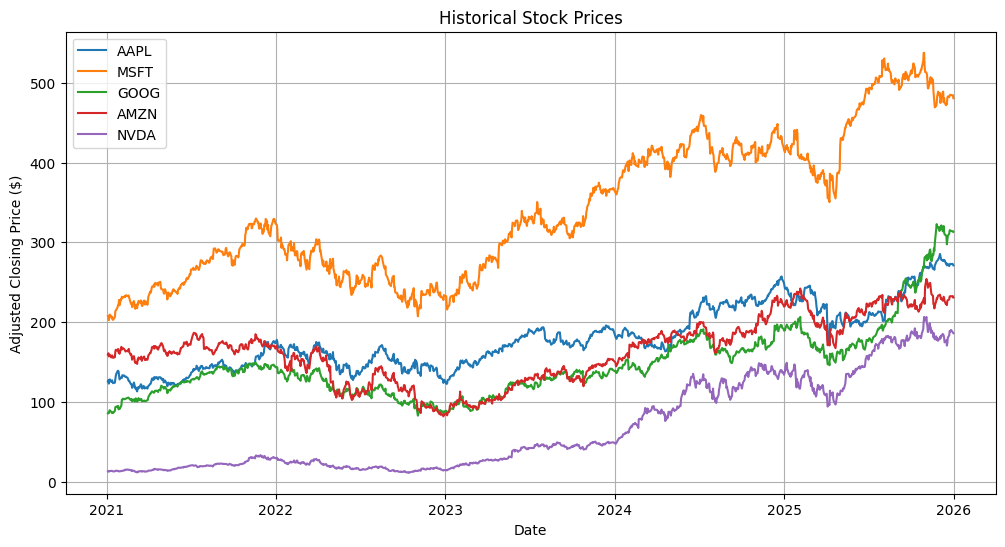

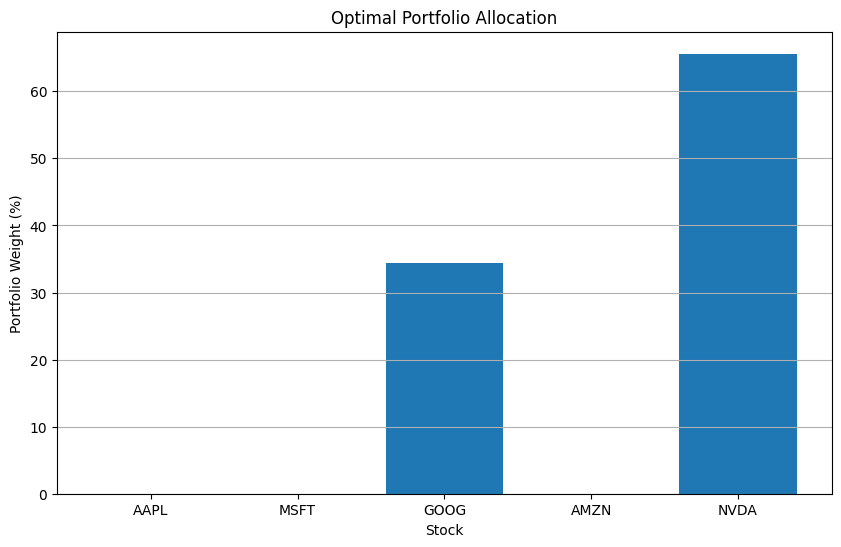

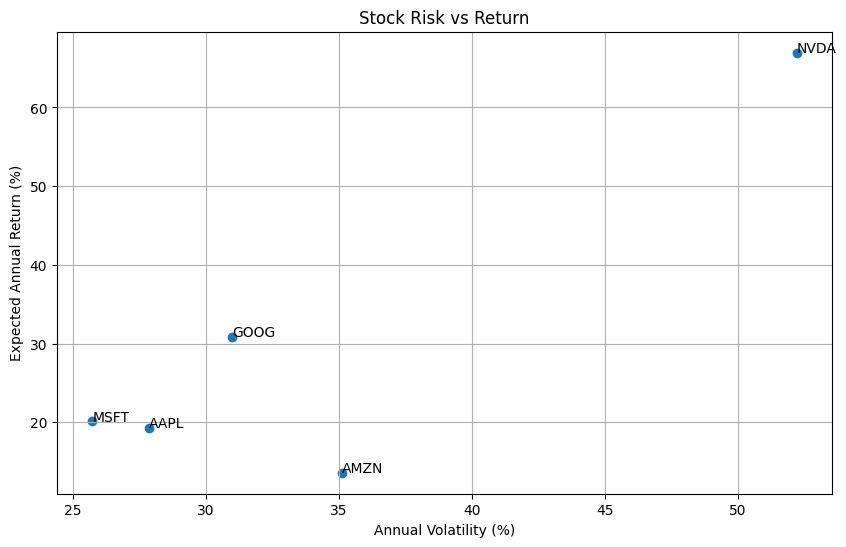

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize


#stocks (can be any)
stocks = ["AAPL", "MSFT", "GOOG", "AMZN", "NVDA"]

#historical prices (chose 5 year period, but can be adjusted)
data = yf.download(
    stocks,
    start="2021-01-01",
    end="2026-01-01",
    auto_adjust=True
)["Close"]


#daily returns
returns = data.pct_change().dropna()

annual_returns = returns.mean() * 252


#annual covariance matrix
cov_matrix = returns.cov() * 252

risk_free_rate = 0.04


#calc portfolio return
def portfolio_return(weights):

    return np.dot(weights, annual_returns)


#calc portfolio volatility
def portfolio_volatility(weights):

    return np.sqrt(
        np.dot(
            weights.T,
            np.dot(cov_matrix, weights)
        )
    )


#calc sharpe ratio
def sharpe_ratio(weights):

    return (
        portfolio_return(weights)
        - risk_free_rate
    ) / portfolio_volatility(weights)


#negative because scipy minimizes
def negative_sharpe(weights):

    return -sharpe_ratio(weights)


#num of stocks
num_stocks = len(stocks)


#start with equal allocations
initial_weights = np.array(
    [1 / num_stocks] * num_stocks
)


#portfolio must equal 100%
constraints = {
    "type": "eq",
    "fun": lambda weights: np.sum(weights) - 1
}


#each stock can be 0%-100%
bounds = tuple(
    (0, 1) for stock in range(num_stocks)
)


#optimize
result = minimize(
    negative_sharpe,
    initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)


#optimal weights
optimal_weights = result.x


print("\nOptimal Portfolio\n")

for stock, weight in zip(stocks, optimal_weights):

    print(f"{stock}: {weight:.2%}")


#portfolio statistics
optimal_return = portfolio_return(optimal_weights)

optimal_volatility = portfolio_volatility(optimal_weights)

optimal_sharpe = sharpe_ratio(optimal_weights)


print(
    f"\nExpected Annual Return: "
    f"{optimal_return:.2%}"
)

print(
    f"Annual Volatility: "
    f"{optimal_volatility:.2%}"
)

print(
    f"Sharpe Ratio: "
    f"{optimal_sharpe:.2f}"
)


#historical stock prices graph
plt.figure(figsize=(12, 6))

for stock in stocks:
    plt.plot(data.index, data[stock], label=stock)

plt.title("Historical Stock Prices")
plt.xlabel("Date")
plt.ylabel("Adjusted Closing Price ($)")
plt.legend()
plt.grid(True)
plt.show()


#pptimal portfolio allocation graph

plt.figure(figsize=(10, 6))

plt.bar(stocks, optimal_weights * 100)

plt.title("Optimal Portfolio Allocation")
plt.xlabel("Stock")
plt.ylabel("Portfolio Weight (%)")
plt.grid(axis="y")
plt.show()


#risk vs return graph
stock_volatility = returns.std() * np.sqrt(252)

plt.figure(figsize=(10, 6))

plt.scatter(
    stock_volatility * 100,
    annual_returns * 100
)

for stock in stocks:
    plt.annotate(
        stock,
        (
            stock_volatility[stock] * 100,
            annual_returns[stock] * 100
        )
    )

plt.title("Stock Risk vs Return")
plt.xlabel("Annual Volatility (%)")
plt.ylabel("Expected Annual Return (%)")
plt.grid(True)
plt.show()
